In [ ]:
from transformers import pipeline

In [ ]:
from transformers import pipeline
senti = pipeline('sentiment-analysis')
reviews = [
'This movie was absolutely breathtaking! A masterpiece.',
'Terrible acting, boring plot. Wasted 2 hours of my life.',
'It was okay. Nothing special but not bad either.',
'Shah Rukh Khan was brilliant. Loved every minute!',
'Ram is more attractive than jayanth ani evaro chepparu',
'KSRM is a great college in asia',
'charan is bad '
]
results = senti(reviews)
for review, result in zip(reviews, results):
  label = result['label']
  score = result['score']
  print(f'{label} ({score:.1%}) | {review[:50]}...')


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

POSITIVE (100.0%) | This movie was absolutely breathtaking! A masterpi...
NEGATIVE (100.0%) | Terrible acting, boring plot. Wasted 2 hours of my...
POSITIVE (99.6%) | It was okay. Nothing special but not bad either....
POSITIVE (100.0%) | Shah Rukh Khan was brilliant. Loved every minute!...
POSITIVE (100.0%) | Ram is more attractive than jayanth ani evaro chep...
POSITIVE (100.0%) | KSRM is a great college in asia...
NEGATIVE (100.0%) | charan is bad ...


In [ ]:
from transformers import pipeline
classifier = pipeline('zero-shot-classification',
model='facebook/bart-large-mnli')
text = 'ksrm is a college of engineering . in aiml we have best students in non crt but cse are worst except few(nen itey aswitha ni analey)'
labels = ['technology','course','computer science','artificial intellignece']
result = classifier(text, candidate_labels=labels)
for label, score in zip(result['labels'], result['scores']):
   print(f'{label:15} {score:.1%}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

technology      57.7%
course          28.7%
artificial intellignece 10.7%
computer science 2.9%


In [ ]:
import transformers
print(transformers.__file__)
print(transformers.__version__)

/usr/local/lib/python3.12/dist-packages/transformers/__init__.py
5.10.1


In [ ]:
!pip install --force-reinstall transformers==4.44.2 tokenizers==0.19.1 --break-system-packages

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from transformers import (AutoTokenizer,
AutoModelForSequenceClassification,
TrainingArguments, Trainer)
from datasets import Dataset
texts = ['Great film!', 'Terrible movie.', 'Average, nothing special.',
'Best film of the year!', 'Waste of time and money.']
labels = [1, 0, 0, 1, 0]
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
def tokenise(batch):
  return tokenizer(batch['text'], padding=True,
truncation=True, max_length=128)
dataset = Dataset.from_dict({'text': texts, 'label': labels})
dataset = dataset.map(tokenise, batched=True)
model = AutoModelForSequenceClassification.from_pretrained(
'bert-base-uncased', num_labels=2
)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


The Indian Space Research Organisation (ISRO) successfully launched its latest Earth observation satellite.


In [ ]:
from transformers import pipeline
qa = pipeline('question-answering',
model='deepset/bert-base-cased-squad2')
context = '''
Sachin Tendulkar played for India for 24 years from 1989 to 2013.
He scored 100 international centuries and 15,921 Test runs.
He was awarded the Bharat Ratna in 2014.
'''
questions = [
'How many international centuries did Sachin score?',
'When did Sachin Tendulkar retire?',
'What award did he receive in 2014?',
]
for q in questions:
  answer = qa(question=q, context=context)
  print(f'Q: {q}')
  print(f'A: {answer["answer"]} (confidence: {answer["score"]:.1%})')


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at deepset/bert-base-cased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Q: How many international centuries did Sachin score?
A: 100 (confidence: 95.2%)
Q: When did Sachin Tendulkar retire?
A: 2013 (confidence: 67.0%)
Q: What award did he receive in 2014?
A: Bharat Ratna (confidence: 97.4%)


In [5]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-hi")
model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-hi")

texts = [
'Machine learning is changing the world.',
'I love cricket and Bollywood movies.',
]

for text in texts:

  input_ids = tokenizer(text, return_tensors="pt").input_ids


  outputs = model.generate(input_ids)


  translated = tokenizer.decode(outputs[0], skip_special_tokens=True)

  print(f'EN: {text}')
  print(f'HI: {translated}')

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

EN: Machine learning is changing the world.
HI: मशीन सीखने दुनिया बदल रहा है।
EN: I love cricket and Bollywood movies.
HI: मैं क्रिकेट और बॉलिंग फिल्म से प्यार करता हूँ.


In [ ]:
from transformers import (AutoTokenizer,
AutoModelForSequenceClassification,
TrainingArguments, Trainer)
from datasets import Dataset

texts = ['Great film!', 'Terrible movie.', 'Average, nothing special.',
'Best film of the year!', 'Waste of time and money.']
labels = [1, 0, 0, 1, 0]

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
def tokenise(batch):

  return tokenizer(batch['text'], padding=True,
truncation=True, max_length=128)
dataset = Dataset.from_dict({'text': texts, 'label': labels})
dataset = dataset.map(tokenise, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
'bert-base-uncased', num_labels=2
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
from transformers import (AutoTokenizer,
AutoModelForSequenceClassification,
TrainingArguments, Trainer)
from datasets import Dataset


texts = ['Great film!', 'Terrible movie.', 'Average, nothing special.',
'Best film of the year!', 'Waste of time and money.']
labels = [1, 0, 0, 1, 0]
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
def tokenise(batch):
  return tokenizer(batch['text'], padding=True,
truncation=True, max_length=128)
dataset = Dataset.from_dict({'text': texts, 'label': labels})
dataset = dataset.map(tokenise, batched=True)
model = AutoModelForSequenceClassification.from_pretrained(
'bert-base-uncased', num_labels=2
)

args = TrainingArguments(
output_dir = './results',
num_train_epochs = 3,
per_device_train_batch_size = 4,
learning_rate = 2e-5,
logging_steps = 10,
save_strategy = 'no',
report_to = 'none'
)
trainer = Trainer(
model = model,
args = args,
train_dataset = dataset,
)
trainer.train()
model.save_pretrained('./my_sentiment_model')
tokenizer.save_pretrained('./my_sentiment_model')
from transformers import pipeline
my_pipeline = pipeline('sentiment-analysis', model='./my_sentiment_model')
print(my_pipeline('This Bollywood film was a pure delight!'))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'LABEL_1', 'score': 0.5276466012001038}]


In [ ]:
import pandas as pd
from transformers import pipeline
reviews_data = [

{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'An absolute masterpiece! Makes you laugh and cry. '
'Aamir Khan delivers one of his finest performances ever.'},
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'Overrated and preachy. The message was fine but '
'execution felt too theatrical and unrealistic.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Incredibly inspiring! Geeta and Babita brought tears '
'to my eyes. Best sports film ever made in India.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Good film but very long. Some scenes dragged unnecessarily.'},

{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Mind-bending and visually stunning. Nolan at his absolutebest.'},
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Too complicated. I had no idea what was happening half thetime.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'Perfect film. The class commentary is brilliant. Deserved everyOscar.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'I expected more from an Oscar winner. Ending felt rushed.'},
]
df = pd.DataFrame(reviews_data)

In [ ]:
sentiment = pipeline('sentiment-analysis',
model='distilbert-base-uncased-finetuned-sst-2-english')
results = sentiment(df['review'].tolist())
df['sentiment'] = [r['label'] for r in results]
df['confidence'] = [r['score'] for r in results]
df['sentiment_score'] = df['confidence'].where(
df['sentiment'] == 'POSITIVE',
1 - df['confidence']
)
print(df[['movie','sentiment','confidence']].to_string(index=False))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


    movie sentiment  confidence
 3 Idiots  POSITIVE    0.999879
 3 Idiots  NEGATIVE    0.999016
   Dangal  POSITIVE    0.999878
   Dangal  NEGATIVE    0.992343
Inception  POSITIVE    0.999849
Inception  NEGATIVE    0.999590
 Parasite  POSITIVE    0.999857
 Parasite  NEGATIVE    0.998913


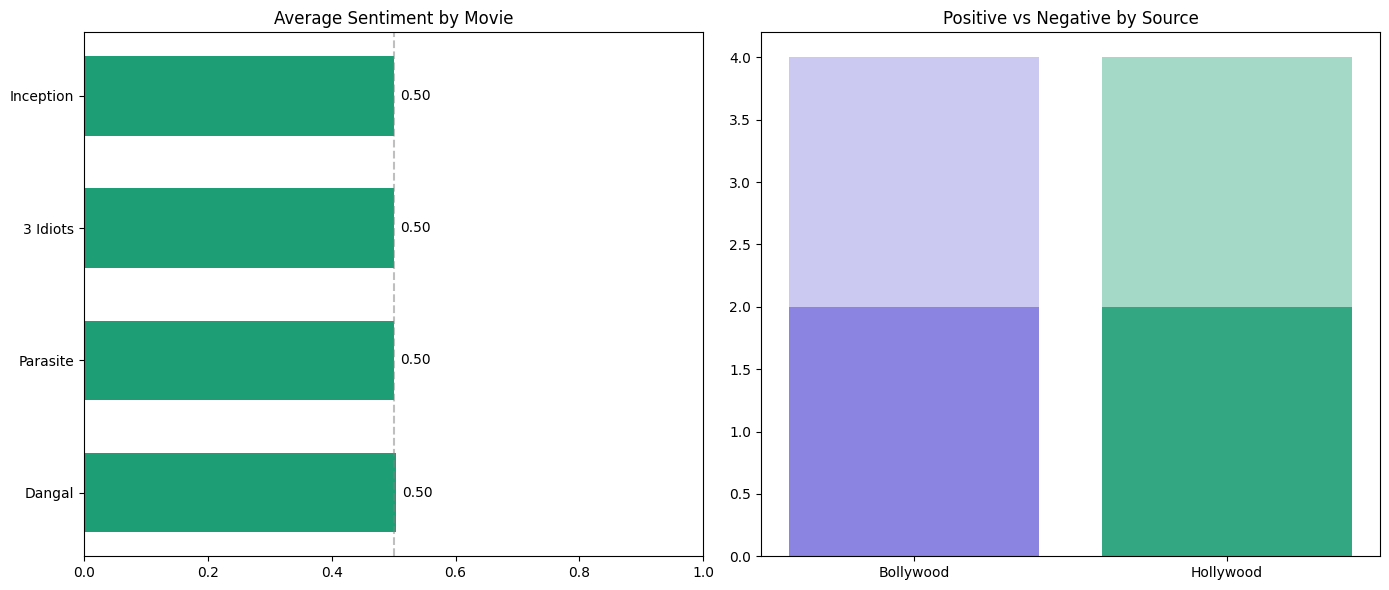

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1 = axes[0]
movie_scores =df.groupby('movie')['sentiment_score'].mean().sort_values(ascending=False)
colours = ['#1D9E75' if v >= 0.5 else '#D85A30' for v in
movie_scores.values]
bars = ax1.barh(movie_scores.index, movie_scores.values, color=colours,
height=0.6)
ax1.set_xlim(0, 1)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Average Sentiment by Movie')
for bar, val in zip(bars, movie_scores.values):
  ax1.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}',
  va='center')
  ax2 = axes[1]
for source, colour in [('Bollywood','#7F77DD'), ('Hollywood','#1D9E75')]:
  subset = df[df['source'] == source]
  pos = (subset['sentiment']=='POSITIVE').sum()
  neg = (subset['sentiment']=='NEGATIVE').sum()
  ax2.bar(source, pos, color=colour, alpha=0.9)
  ax2.bar(source, neg, bottom=pos, color=colour, alpha=0.4)
  ax2.set_title('Positive vs Negative by Source')
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def analyse_review(review_text, movie_name='Unknown'):
  result = sentiment(review_text)[0]
  label = result['label']
  conf = result['score']
  if label == 'POSITIVE':
    score = conf
    verdict = 'LOVED IT' if conf > 0.95 else 'LIKED IT'
  else:
    score = 1 - conf
    verdict = 'HATED IT' if conf > 0.95 else 'DISLIKED IT'
  print(f'Movie : {movie_name}')
  print(f'Verdict : {verdict}')
  print(f'Score : {score:.1%} positive')
  print(f'Review : {review_text[:80]}...')
  return {'movie': movie_name, 'verdict': verdict, 'score': score}
analyse_review(
'Rajkummar Rao was phenomenal. A raw, honest performance. '
'Easily the best Hindi film of the decade.',
'Stree'
)

Movie : Stree
Verdict : LOVED IT
Score : 100.0% positive
Review : Rajkummar Rao was phenomenal. A raw, honest performance. Easily the best Hindi f...


{'movie': 'Stree', 'verdict': 'LOVED IT', 'score': 0.9998749494552612}